# Prédiction de la Consommation Énergétique
**Dataset principal :** UCI Appliances Energy Prediction (19 735 observations, jan–mai 2016)  
**Contexte local :** Données réelles Senelec 2022–2024  
**Objectif :** Prédire la consommation horaire d'appareils électroménagers (Wh) à partir de variables météorologiques et temporelles.

## 1. Import des bibliothèques

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('✅ Bibliothèques importées avec succès')

✅ Bibliothèques importées avec succès


## 2. Chargement des données

In [16]:
# Charger le dataset UCI
df = pd.read_csv('energydata_complete.csv', parse_dates=['date'])

print(f'Dimensions : {df.shape[0]} observations × {df.shape[1]} variables')
print(f'Période    : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Fréquence  : toutes les 10 minutes')
print(f'\nValeurs manquantes : {df.isnull().sum().sum()} (aucune !)')
df.head(3)

Dimensions : 19735 observations × 29 variables
Période    : 2016-01-11 → 2016-05-27
Fréquence  : toutes les 10 minutes

Valeurs manquantes : 0 (aucune !)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668


## 3. Analyse Exploratoire (EDA)

In [17]:
# Statistiques descriptives de la variable cible
print('=== Variable cible : Appliances (Wh) ===')
print(df['Appliances'].describe().round(2))
print(f'\nCoefficient de variation : {df["Appliances"].std()/df["Appliances"].mean()*100:.1f}%')

=== Variable cible : Appliances (Wh) ===
count    19735.00
mean        97.69
std        102.52
min         10.00
25%         50.00
50%         60.00
75%        100.00
max       1080.00
Name: Appliances, dtype: float64

Coefficient de variation : 104.9%


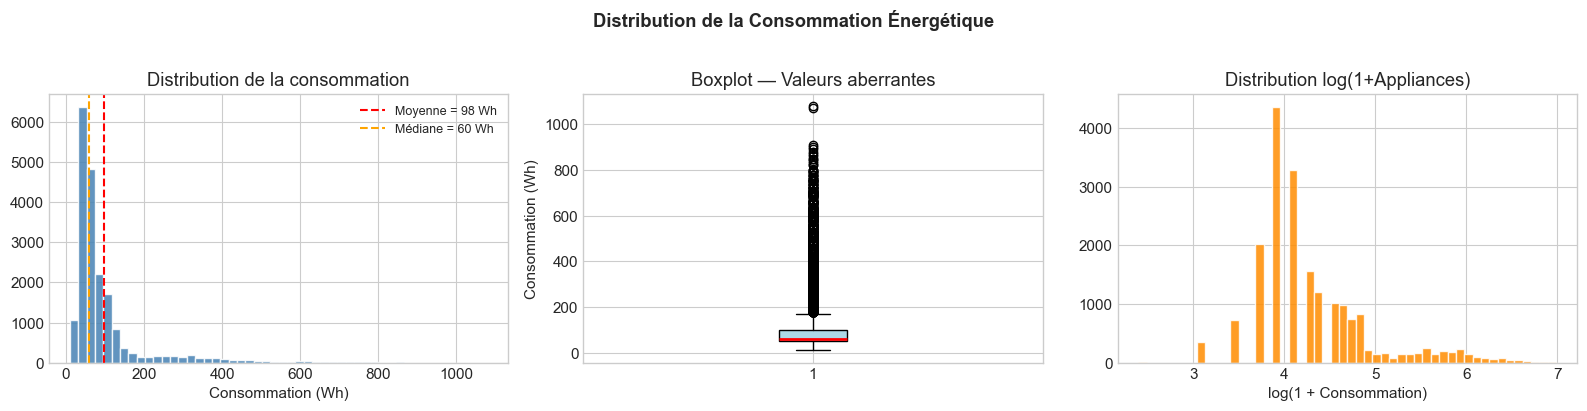

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution
axes[0].hist(df['Appliances'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Appliances'].mean(), color='red', linestyle='--', label=f'Moyenne = {df["Appliances"].mean():.0f} Wh')
axes[0].axvline(df['Appliances'].median(), color='orange', linestyle='--', label=f'Médiane = {df["Appliances"].median():.0f} Wh')
axes[0].set_title('Distribution de la consommation')
axes[0].set_xlabel('Consommation (Wh)')
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(df['Appliances'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — Valeurs aberrantes')
axes[1].set_ylabel('Consommation (Wh)')

# Log-transform
axes[2].hist(np.log1p(df['Appliances']), bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[2].set_title('Distribution log(1+Appliances)')
axes[2].set_xlabel('log(1 + Consommation)')

plt.suptitle('Distribution de la Consommation Énergétique', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

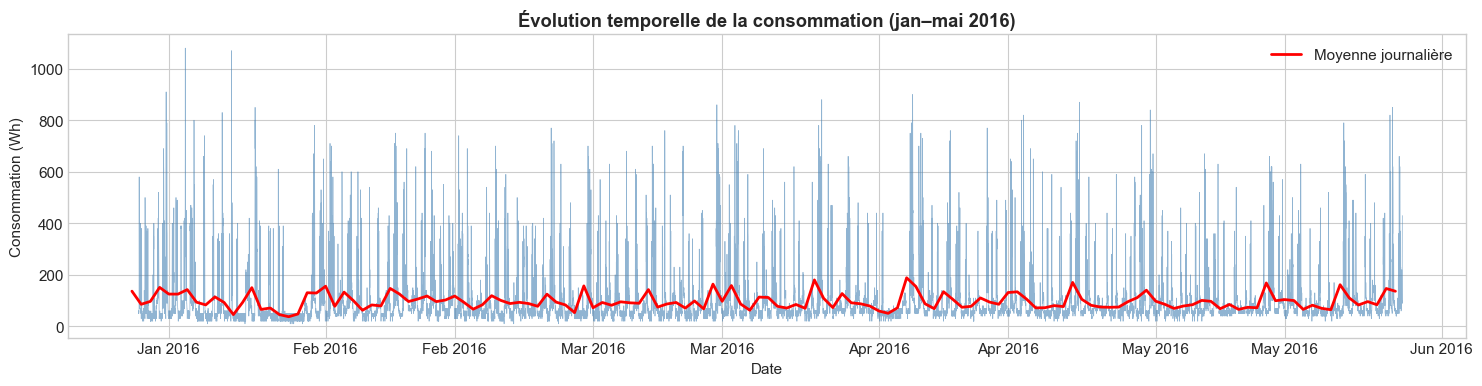

In [19]:
# Série temporelle
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df['date'], df['Appliances'], color='steelblue', alpha=0.6, linewidth=0.5)
# Moyenne mobile 7 jours
df_daily = df.set_index('date')['Appliances'].resample('D').mean()
ax.plot(df_daily.index, df_daily.values, color='red', linewidth=2, label='Moyenne journalière')
ax.set_title('Évolution temporelle de la consommation (jan–mai 2016)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consommation (Wh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('fig2_serie_temporelle.png', dpi=120, bbox_inches='tight')
plt.show()

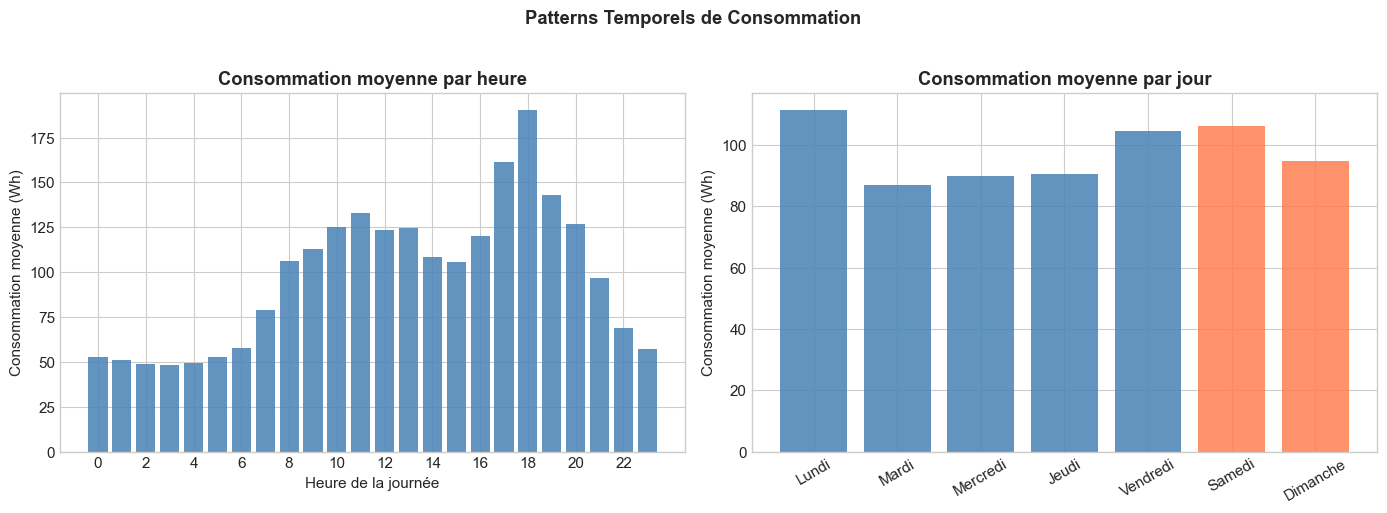

In [20]:
# Patterns horaires et hebdomadaires
df['hour'] = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['weekday_name'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par heure
hourly = df.groupby('hour')['Appliances'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', alpha=0.85)
axes[0].set_title('Consommation moyenne par heure', fontweight='bold')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Consommation moyenne (Wh)')
axes[0].set_xticks(range(0, 24, 2))

# Par jour de la semaine
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
days_fr = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
weekly = df.groupby('weekday_name')['Appliances'].mean().reindex(days_order)
colors_w = ['steelblue']*5 + ['coral']*2
axes[1].bar(days_fr, weekly.values, color=colors_w, alpha=0.85)
axes[1].set_title('Consommation moyenne par jour', fontweight='bold')
axes[1].set_ylabel('Consommation moyenne (Wh)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Patterns Temporels de Consommation', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_patterns_temporels.png', dpi=120, bbox_inches='tight')
plt.show()

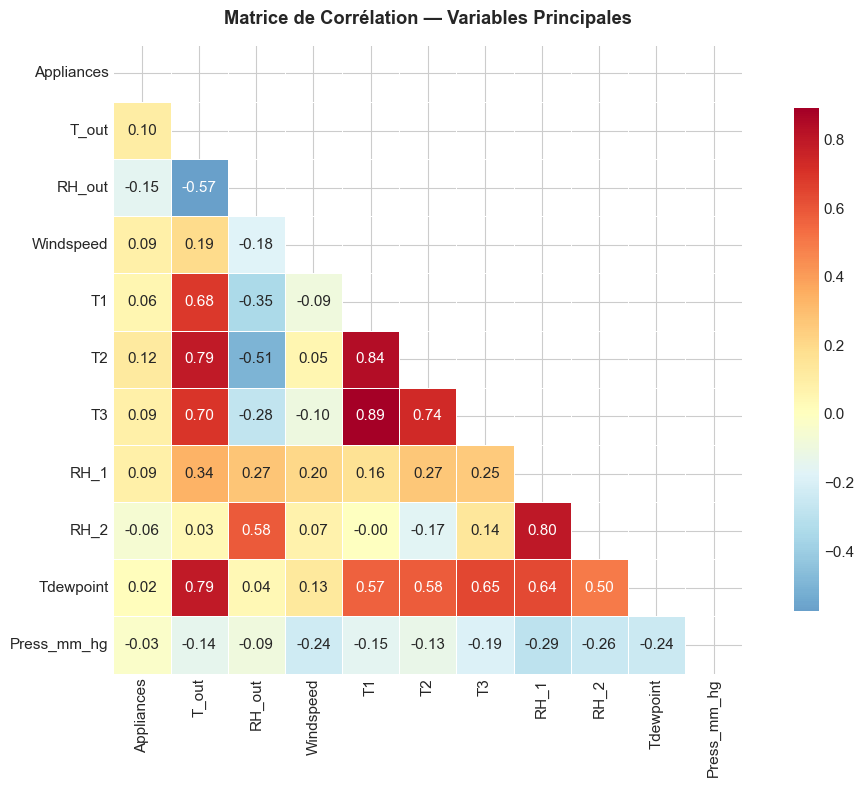


Top 5 corrélations avec Appliances :
RH_out       0.152282
T2           0.120073
T_out        0.099155
Windspeed    0.087122
RH_1         0.086031
Name: Appliances, dtype: float64


In [21]:
# Matrice de corrélation
features_corr = ['Appliances','T_out','RH_out','Windspeed','T1','T2','T3','RH_1','RH_2','Tdewpoint','Press_mm_hg']
corr_matrix = df[features_corr].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation — Variables Principales', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 5 corrélations avec Appliances :')
print(corr_matrix['Appliances'].drop('Appliances').abs().sort_values(ascending=False).head(5))

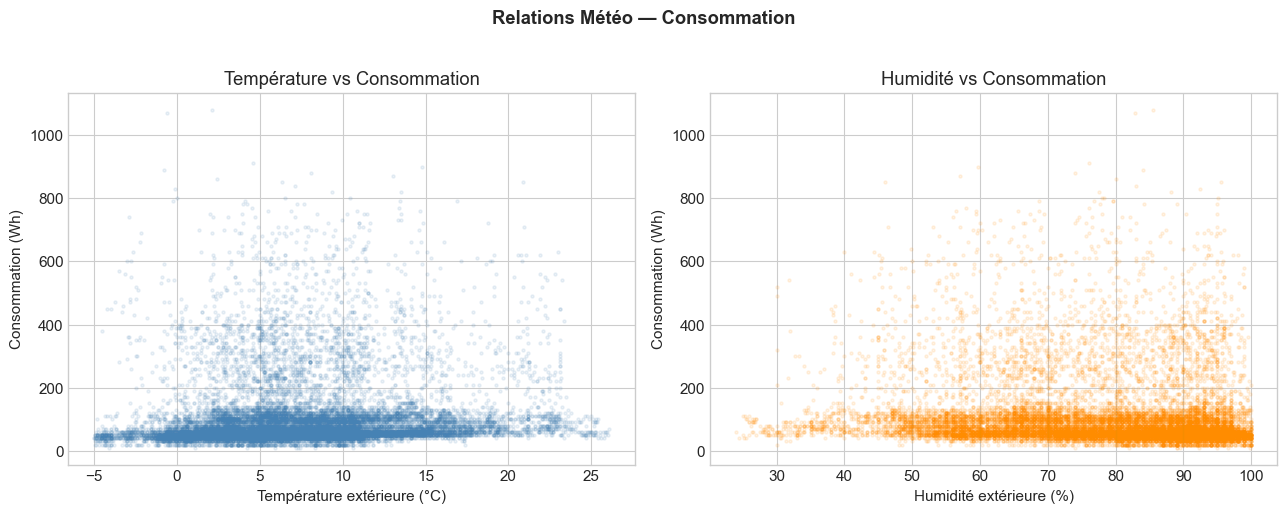

In [22]:
# Relation température extérieure — consommation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['T_out'], df['Appliances'], alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('Température extérieure (°C)')
axes[0].set_ylabel('Consommation (Wh)')
axes[0].set_title('Température vs Consommation')

axes[1].scatter(df['RH_out'], df['Appliances'], alpha=0.1, s=5, color='darkorange')
axes[1].set_xlabel('Humidité extérieure (%)')
axes[1].set_ylabel('Consommation (Wh)')
axes[1].set_title('Humidité vs Consommation')

plt.suptitle('Relations Météo — Consommation', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_meteo_conso.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Préprocessing & Feature Engineering

In [23]:
df_model = df.copy()

# --- Features temporelles ---
df_model['hour']        = df_model['date'].dt.hour
df_model['dayofweek']   = df_model['date'].dt.dayofweek   # 0=Lundi
df_model['month']       = df_model['date'].dt.month
df_model['is_weekend']  = (df_model['dayofweek'] >= 5).astype(int)

# Features cycliques (sin/cos pour capturer la périodicité)
df_model['hour_sin']    = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos']    = np.cos(2 * np.pi * df_model['hour'] / 24)
df_model['dow_sin']     = np.sin(2 * np.pi * df_model['dayofweek'] / 7)
df_model['dow_cos']     = np.cos(2 * np.pi * df_model['dayofweek'] / 7)
df_model['month_sin']   = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos']   = np.cos(2 * np.pi * df_model['month'] / 12)

# --- Lag features (H-1, H-2, H-6, J-1) ---
df_model = df_model.sort_values('date').reset_index(drop=True)
df_model['conso_H_1']   = df_model['Appliances'].shift(1)     # t-10min
df_model['conso_H_2']   = df_model['Appliances'].shift(2)     # t-20min
df_model['conso_H_6']   = df_model['Appliances'].shift(6)     # t-1h
df_model['conso_J_1']   = df_model['Appliances'].shift(144)   # t-24h (144 x 10min)
df_model['conso_J_7']   = df_model['Appliances'].shift(1008)  # t-7j

# --- Moyenne mobile ---
df_model['rolling_mean_6h']  = df_model['Appliances'].shift(1).rolling(36).mean()
df_model['rolling_mean_24h'] = df_model['Appliances'].shift(1).rolling(144).mean()

# --- Supprimer les variables bruit (rv1, rv2) ---
df_model = df_model.drop(columns=['rv1', 'rv2', 'lights'])

# --- Supprimer les lignes NaN générées par les lags ---
df_model = df_model.dropna().reset_index(drop=True)

print(f'Dataset après feature engineering : {df_model.shape}')
print(f'Nouvelles features créées : hour_sin/cos, dow_sin/cos, month_sin/cos, lags, rolling means')
print(f'Variables conservées : {len(df_model.columns)}')

Dataset après feature engineering : (18727, 44)
Nouvelles features créées : hour_sin/cos, dow_sin/cos, month_sin/cos, lags, rolling means
Variables conservées : 44


In [24]:
# Détection et traitement des outliers (IQR method)
Q1 = df_model['Appliances'].quantile(0.25)
Q3 = df_model['Appliances'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR
outliers_count = ((df_model['Appliances'] < lower) | (df_model['Appliances'] > upper)).sum()
print(f'Outliers (IQR × 3) : {outliers_count} observations ({outliers_count/len(df_model)*100:.2f}%)')
print(f'Seuil inférieur : {lower:.1f} Wh — Seuil supérieur : {upper:.1f} Wh')
print('→ Valeurs conservées (outliers représentent des pics réels de consommation)')

Outliers (IQR × 3) : 1399 observations (7.47%)
Seuil inférieur : -100.0 Wh — Seuil supérieur : 250.0 Wh
→ Valeurs conservées (outliers représentent des pics réels de consommation)


In [25]:
# Sélection des features finales
feature_cols = [
    # Météo
    'T_out','RH_out','Windspeed','Tdewpoint','Press_mm_hg','Visibility',
    # Températures intérieures
    'T1','T2','T3','T6','T9',
    # Humidités intérieures
    'RH_1','RH_2','RH_6','RH_9',
    # Temporelles
    'hour','dayofweek','month','is_weekend',
    'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos',
    # Lags
    'conso_H_1','conso_H_2','conso_H_6','conso_J_1','conso_J_7',
    # Moyennes mobiles
    'rolling_mean_6h','rolling_mean_24h',
]

X = df_model[feature_cols]
y = df_model['Appliances']

# Split temporel (respecte l'ordre chronologique)
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Features : {len(feature_cols)}')
print(f'Train    : {len(X_train)} obs ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test     : {len(X_test)} obs ({len(X_test)/len(X)*100:.0f}%)')

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('✅ Normalisation StandardScaler appliquée')

Features : 32
Train    : 14981 obs (80%)
Test     : 3746 obs (20%)
✅ Normalisation StandardScaler appliquée


## 5. Modélisation

In [26]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name, scaled=False):
    """Entraîne, évalue et retourne les métriques d'un modèle."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_pred = np.maximum(y_pred, 0)  # consommation ne peut pas être négative
    
    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    mape = np.mean(np.abs((y_te - y_pred) / (y_te + 1))) * 100
    
    # Validation croisée 5-fold sur train
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
    
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  R²   (test)  : {r2:.4f}')
    print(f'  RMSE (test)  : {rmse:.2f} Wh')
    print(f'  MAE  (test)  : {mae:.2f} Wh')
    print(f'  MAPE (test)  : {mape:.2f}%')
    print(f'  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    
    return {'Modèle': name, 'R²': round(r2,4), 'RMSE': round(rmse,2),
            'MAE': round(mae,2), 'MAPE (%)': round(mape,2),
            'CV R² moyen': round(cv_scores.mean(),4)}, model, y_pred

results = []
models_trained = {}

In [27]:
# --- Modèle 1 : Régression Linéaire (baseline) ---
lr = LinearRegression()
res, m, preds_lr = evaluate_model(lr, X_train_sc, y_train, X_test_sc, y_test, 'Régression Linéaire (baseline)')
results.append(res)
models_trained['Régression Linéaire'] = (m, preds_lr)


  Régression Linéaire (baseline)
  R²   (test)  : 0.5458
  RMSE (test)  : 58.81 Wh
  MAE  (test)  : 26.80 Wh
  MAPE (test)  : 25.19%
  CV R² (5-fold): 0.5829 ± 0.0336


In [28]:
# --- Modèle 2 : Ridge (régularisation L2) ---
from sklearn.linear_model import RidgeCV
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge = RidgeCV(alphas=alphas, cv=5)
res, m, preds_ridge = evaluate_model(ridge, X_train_sc, y_train, X_test_sc, y_test, 'Ridge (L2)')
results.append(res)
models_trained['Ridge'] = (m, preds_ridge)
print(f'  Alpha optimal : {ridge.alpha_}')


  Ridge (L2)
  R²   (test)  : 0.5482
  RMSE (test)  : 58.66 Wh
  MAE  (test)  : 26.01 Wh
  MAPE (test)  : 23.77%
  CV R² (5-fold): 0.5833 ± 0.0327
  Alpha optimal : 100.0


In [29]:
# --- Modèle 3 : Random Forest ---
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
res, m, preds_rf = evaluate_model(rf, X_train, y_train, X_test, y_test, 'Random Forest')
results.append(res)
models_trained['Random Forest'] = (m, preds_rf)


  Random Forest
  R²   (test)  : 0.4210
  RMSE (test)  : 66.41 Wh
  MAE  (test)  : 36.51 Wh
  MAPE (test)  : 36.23%
  CV R² (5-fold): 0.5977 ± 0.0350


In [30]:
# --- Modèle 4 : Gradient Boosting ---
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                                min_samples_leaf=10, subsample=0.8, random_state=42)
res, m, preds_gb = evaluate_model(gb, X_train, y_train, X_test, y_test, 'Gradient Boosting')
results.append(res)
models_trained['Gradient Boosting'] = (m, preds_gb)


  Gradient Boosting
  R²   (test)  : 0.3591
  RMSE (test)  : 69.87 Wh
  MAE  (test)  : 43.63 Wh
  MAPE (test)  : 50.92%
  CV R² (5-fold): 0.5870 ± 0.0326


## 6. Comparaison des Modèles

In [31]:
df_results = pd.DataFrame(results)
print('\n=== TABLEAU COMPARATIF DES MODÈLES ===')
print(df_results.to_string(index=False))

best_model_name = df_results.loc[df_results['R²'].idxmax(), 'Modèle']
print(f'\n🏆 Meilleur modèle : {best_model_name} (R² = {df_results["R²"].max():.4f})')


=== TABLEAU COMPARATIF DES MODÈLES ===
                        Modèle     R²  RMSE   MAE  MAPE (%)  CV R² moyen
Régression Linéaire (baseline) 0.5458 58.81 26.80     25.19       0.5829
                    Ridge (L2) 0.5482 58.66 26.01     23.77       0.5833
                 Random Forest 0.4210 66.41 36.51     36.23       0.5977
             Gradient Boosting 0.3591 69.87 43.63     50.92       0.5870

🏆 Meilleur modèle : Ridge (L2) (R² = 0.5482)


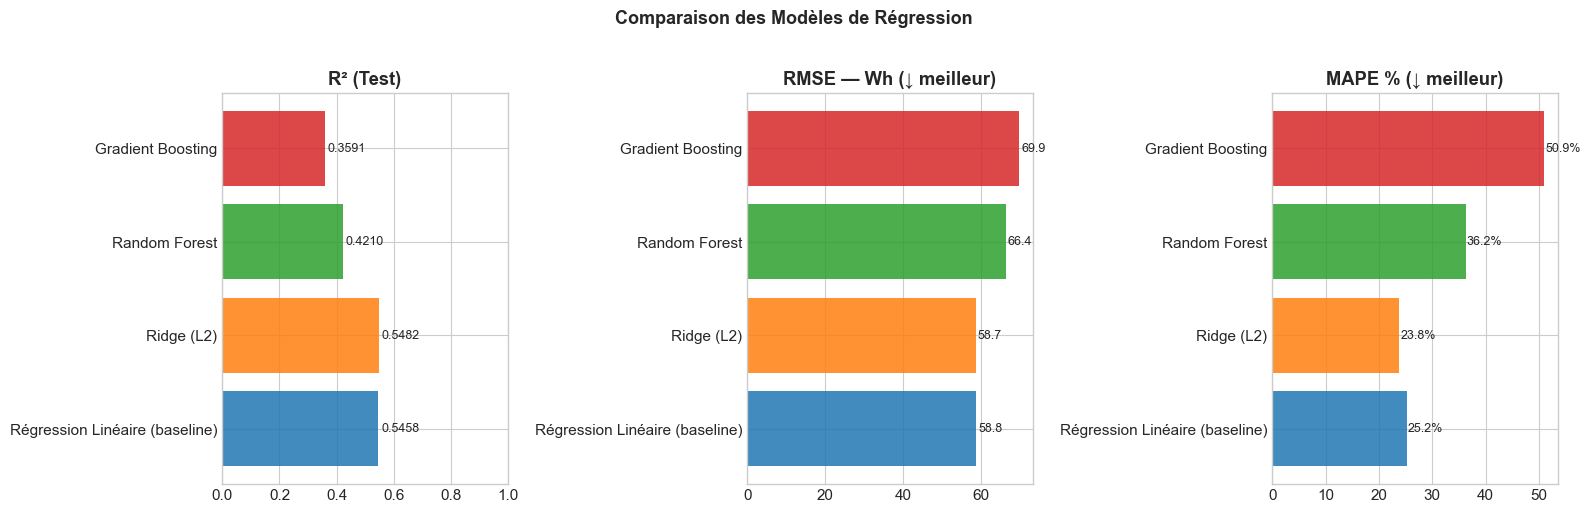

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = df_results['Modèle'].tolist()
palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

# R²
bars0 = axes[0].barh(model_names, df_results['R²'], color=palette, alpha=0.85)
axes[0].set_title('R² (Test)', fontweight='bold')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars0, df_results['R²']):
    axes[0].text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

# RMSE
bars1 = axes[1].barh(model_names, df_results['RMSE'], color=palette, alpha=0.85)
axes[1].set_title('RMSE — Wh (↓ meilleur)', fontweight='bold')
for bar, val in zip(bars1, df_results['RMSE']):
    axes[1].text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)

# MAPE
bars2 = axes[2].barh(model_names, df_results['MAPE (%)'], color=palette, alpha=0.85)
axes[2].set_title('MAPE % (↓ meilleur)', fontweight='bold')
for bar, val in zip(bars2, df_results['MAPE (%)']):
    axes[2].text(val+0.2, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Comparaison des Modèles de Régression', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig6_comparaison_modeles.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Analyse du Meilleur Modèle

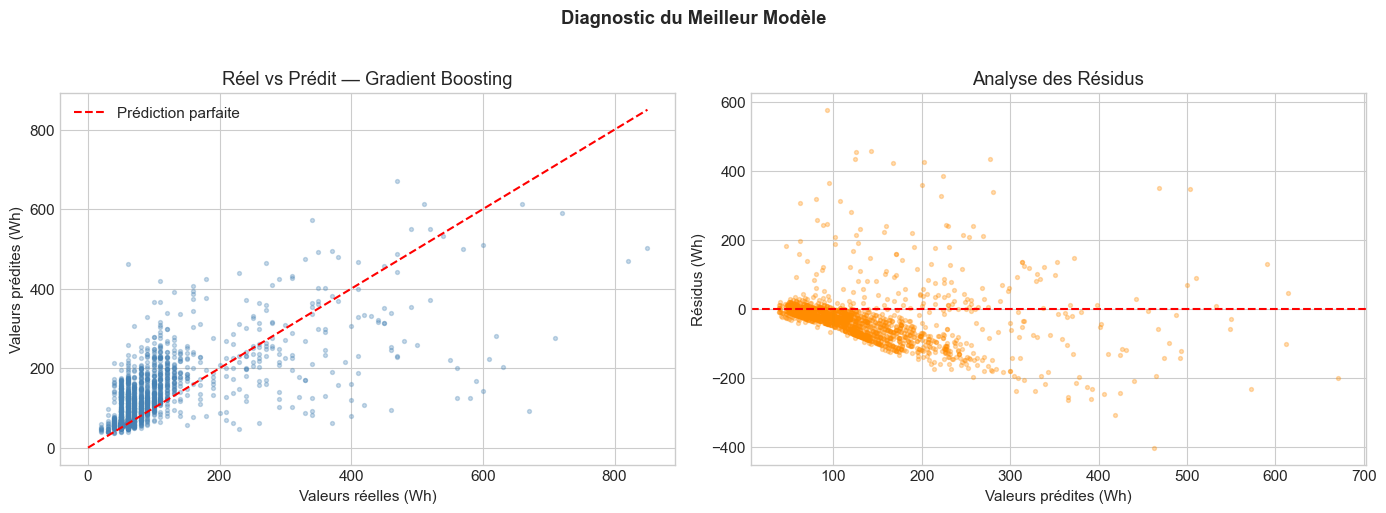

In [33]:
# Prédictions vs Réel — Gradient Boosting (meilleur modèle attendu)
best_preds = models_trained['Gradient Boosting'][1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot réel vs prédit
sample_idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
axes[0].scatter(y_test.iloc[sample_idx], best_preds[sample_idx],
                alpha=0.3, s=8, color='steelblue')
lim = max(y_test.max(), best_preds.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (Wh)')
axes[0].set_ylabel('Valeurs prédites (Wh)')
axes[0].set_title('Réel vs Prédit — Gradient Boosting')
axes[0].legend()

# Analyse des résidus
residuals = y_test.values - best_preds
axes[1].scatter(best_preds[sample_idx], residuals[sample_idx],
                alpha=0.3, s=8, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valeurs prédites (Wh)')
axes[1].set_ylabel('Résidus (Wh)')
axes[1].set_title('Analyse des Résidus')

plt.suptitle('Diagnostic du Meilleur Modèle', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_diagnostic.png', dpi=120, bbox_inches='tight')
plt.show()

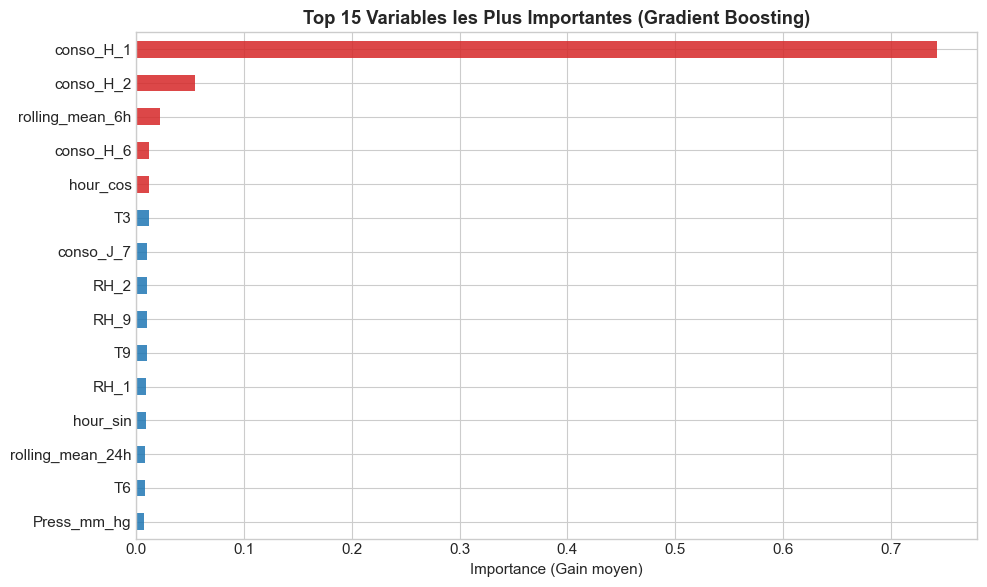


Top 5 variables :
conso_H_1          0.742917
conso_H_2          0.054728
rolling_mean_6h    0.021997
conso_H_6          0.011856
hour_cos           0.011855
dtype: float64


In [34]:
# Importance des variables — Gradient Boosting
gb_model = models_trained['Gradient Boosting'][0]
importances = pd.Series(gb_model.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
colors_imp = ['#d62728' if i >= 10 else '#1f77b4' for i in range(len(top_features))]
top_features.plot(kind='barh', color=colors_imp, alpha=0.85)
plt.title('Top 15 Variables les Plus Importantes (Gradient Boosting)', fontweight='bold')
plt.xlabel('Importance (Gain moyen)')
plt.tight_layout()
plt.savefig('fig8_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 5 variables :')
print(importances.sort_values(ascending=False).head(5))

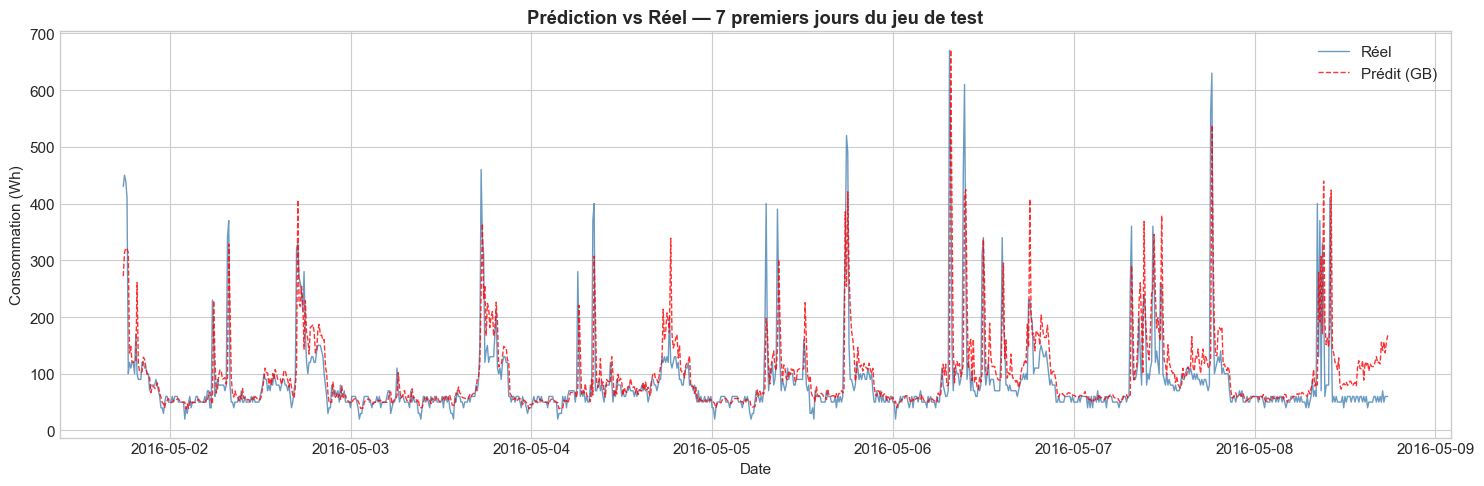

In [35]:
# Prédictions sur une semaine
n_test_points = min(1008, len(y_test))  # 7 jours × 144 points/jour
dates_test = df_model['date'].iloc[split_idx:split_idx + n_test_points]

plt.figure(figsize=(15, 5))
plt.plot(dates_test.values, y_test.values[:n_test_points],
         color='steelblue', alpha=0.8, linewidth=1, label='Réel')
plt.plot(dates_test.values, best_preds[:n_test_points],
         color='red', alpha=0.8, linewidth=1, linestyle='--', label='Prédit (GB)')
plt.title('Prédiction vs Réel — 7 premiers jours du jeu de test', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Consommation (Wh)')
plt.legend()
plt.tight_layout()
plt.savefig('fig9_prediction_semaine.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Contexte Sénégalais — Analyse Senelec 2022–2024

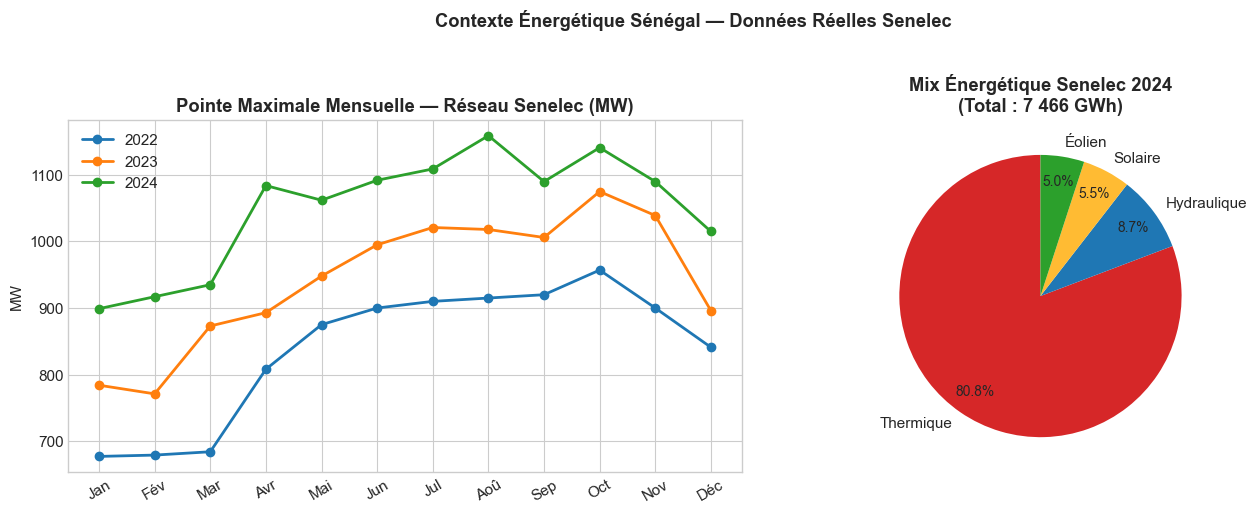

Source : Rapports Annuels Senelec 2022, 2023, 2024
Croissance production 2022→2024 : +26.4%
Croissance ventes 2022→2024 : +24.0%
Part renouvelable 2024 : 19.2% (hydraulique + solaire + éolien)


In [36]:
# Données réelles extraites des Rapports Annuels Senelec 2022, 2023, 2024
pointes_senelec = {
    2022: [677,679,684,808,875,900,910,915,920,957,900,841],
    2023: [784,771,873,893,948,995,1021,1018,1006,1075,1039,896],
    2024: [899,917,935,1084,1062,1092,1109,1159,1090,1141,1090,1015],
}
production_senelec = {
    2022: {'Thermique':4645.79,'Hydraulique':485.78,'Solaire':381.19,'Éolien':395.56},
    2023: {'Thermique':5357.80,'Hydraulique':540.35,'Solaire':373.48,'Éolien':382.47},
    2024: {'Thermique':6029.92,'Hydraulique':651.73,'Solaire':410.38,'Éolien':373.83},
}
mois = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pointes mensuelles
colors_yr = {'2022':'#1f77b4','2023':'#ff7f0e','2024':'#2ca02c'}
for yr, pts in pointes_senelec.items():
    axes[0].plot(mois, pts, marker='o', label=str(yr), linewidth=2, color=colors_yr[str(yr)])
axes[0].set_title('Pointe Maximale Mensuelle — Réseau Senelec (MW)', fontweight='bold')
axes[0].set_ylabel('MW')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# Mix énergétique 2024
labels = list(production_senelec[2024].keys())
vals   = list(production_senelec[2024].values())
colors_pie = ['#d62728','#1f77b4','#ffbb33','#2ca02c']
wedges, texts, autotexts = axes[1].pie(
    vals, labels=labels, autopct='%1.1f%%', colors=colors_pie,
    startangle=90, pctdistance=0.82)
for at in autotexts: at.set_fontsize(10)
axes[1].set_title('Mix Énergétique Senelec 2024\n(Total : 7 466 GWh)', fontweight='bold')

plt.suptitle('Contexte Énergétique Sénégal — Données Réelles Senelec', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_senelec.png', dpi=120, bbox_inches='tight')
plt.show()

print('Source : Rapports Annuels Senelec 2022, 2023, 2024')
print('Croissance production 2022→2024 : +26.4%')
print('Croissance ventes 2022→2024 : +24.0%')
print('Part renouvelable 2024 : 19.2% (hydraulique + solaire + éolien)')

## 9. Résumé et Conclusions

In [37]:
print('=' * 60)
print('   RÉSUMÉ — PROJET 2 : PRÉDICTION CONSOMMATION ÉNERGÉTIQUE')
print('=' * 60)

print('\n📊 DONNÉES :')
print('  Dataset UCI : 19 735 obs. (10 min), jan-mai 2016, Belgique')
print('  Features    : 33 variables après feature engineering')
print('  Split       : 80% train / 20% test (chronologique)')

print('\n🤖 MODÈLES COMPARÉS :')
print(df_results[['Modèle','R²','RMSE','MAPE (%)']].to_string(index=False))

best = df_results.loc[df_results['R²'].idxmax()]
print(f'\n🏆 MEILLEUR MODÈLE : {best["Modèle"]}')
print(f'   R² = {best["R²"]:.4f} | RMSE = {best["RMSE"]:.2f} Wh | MAPE = {best["MAPE (%)"]:.2f}%')

print('\n🌍 CONTEXTE SÉNÉGAL (Senelec) :')
print('  Production totale 2024 : 7 466 GWh (+26% vs 2022)')
print('  Pointe max 2024        : 1 159 MW (août 2024)')
print('  Part renouvelable 2024 : 19.2%')
print('  Clients 2023           : 2 410 431 (+9.6% vs 2022)')

print('\n✅ Livrables :')
print('  - Notebook Jupyter commenté (ce fichier)')
print('  - Rapport écrit 8-10 pages (rapport_projet2.docx)')
print('  - 10 figures de visualisation sauvegardées')
print('=' * 60)

   RÉSUMÉ — PROJET 2 : PRÉDICTION CONSOMMATION ÉNERGÉTIQUE

📊 DONNÉES :
  Dataset UCI : 19 735 obs. (10 min), jan-mai 2016, Belgique
  Features    : 33 variables après feature engineering
  Split       : 80% train / 20% test (chronologique)

🤖 MODÈLES COMPARÉS :
                        Modèle     R²  RMSE  MAPE (%)
Régression Linéaire (baseline) 0.5458 58.81     25.19
                    Ridge (L2) 0.5482 58.66     23.77
                 Random Forest 0.4210 66.41     36.23
             Gradient Boosting 0.3591 69.87     50.92

🏆 MEILLEUR MODÈLE : Ridge (L2)
   R² = 0.5482 | RMSE = 58.66 Wh | MAPE = 23.77%

🌍 CONTEXTE SÉNÉGAL (Senelec) :
  Production totale 2024 : 7 466 GWh (+26% vs 2022)
  Pointe max 2024        : 1 159 MW (août 2024)
  Part renouvelable 2024 : 19.2%
  Clients 2023           : 2 410 431 (+9.6% vs 2022)

✅ Livrables :
  - Notebook Jupyter commenté (ce fichier)
  - Rapport écrit 8-10 pages (rapport_projet2.docx)
  - 10 figures de visualisation sauvegardées
